# Master of Data Science at UBCO — DATA589  
# Lab 1 Extended — Image & Video Foundations + PyTorch for Computer Vision

**Course:** DATA589 Applied Computer Vision and Deep Learning  
**Level:** Master's  
**Topic:** Image/video basics, OpenCV fundamentals, PyTorch tensors, datasets, and CNNs  
**Estimated time:** 3–4 hours  
**Recommended platform:** **Google Colab**

## Why this lab?

In **Lecture 1**, you learned the foundations of computer vision:
- how images and videos are represented numerically,
- what pixels, channels, and frames mean,
- and why structure matters.

In **Lecture 2 (up to slide 35)**, you learned:
- representation learning,
- why fully connected networks are not ideal for images,
- how convolution extracts local features,
- and why CNNs are a better fit for visual data.

This lab **bridges practice and theory**. It shows you:
1. How to load, manipulate, and analyze images and videos in Python using **OpenCV**
2. Key image processing operations: edge detection, contour detection
3. Video metadata and codec concepts
4. Then: PyTorch fundamentals and your first CNN

By the end, you will feel confident working with real visual data and understand the deep learning pipeline that processes it.

---

## Running this notebook in Google Colab

1. Upload this notebook to **Google Colab**.
2. In Colab, go to **Runtime → Change runtime type**.
3. Select **GPU** if one is available.
4. Run cells **from top to bottom** in order.
5. Some cells use OpenCV; Colab has it pre-installed, but you may need `ffmpeg` for video work.

---

## Submission Instructions

Submit:
1. Your completed notebook  
2. The output cells intact  
3. Short written answers in the markdown cells where requested  

## Rules

- You may discuss concepts with classmates.
- You may use AI assistants for clarification and debugging support.
- You may **not** ask AI tools to complete the assignment for you.
- Your final notebook must reflect **your own understanding and work**.

## Learning Outcomes

By the end of this lab, you should be able to:

**Image & Video Foundations:**
- load and display images using OpenCV,
- understand color spaces (RGB, BGR, grayscale),
- apply edge detection (Canny),
- detect and draw contours,
- load videos and extract metadata,
- understand video codecs, containers, and frame rates.

**PyTorch & Deep Learning:**
- create and inspect tensors in PyTorch,
- explain tensor shape, dimension, and image layout,
- perform basic tensor computations,
- load and visualize the FashionMNIST dataset,
- build a simple fully connected baseline,
- build and train a small CNN,
- compare FCN vs CNN on image data.

> The goal is not to memorize syntax. The goal is to become comfortable enough with modern CV tools that you can read shapes, process images, build small models, and debug early computer vision pipelines.

---

# PART A: Image & Video Foundations

## Part A.0 — Setup for Image & Video Processing

Run the cell below to import OpenCV, numpy, and set up visualization.

**Note:** In Google Colab, OpenCV is usually pre-installed. If you run this locally, you may need to install it:
```bash
pip install opencv-python opencv-contrib-python
```

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import urllib.request
import os

print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

# Create a data directory for any downloaded images
os.makedirs("./cv_data", exist_ok=True)
print("Setup complete!")

OpenCV version: 4.13.0
NumPy version: 2.0.2
Setup complete!


## Part A.1 — Understanding Images: Pixels, Channels, and Color Spaces

### What is a Digital Image?

A digital image is a **2D (or 3D with color) grid of numbers**.

- **Grayscale image:** shape `(Height, Width)` — each value is 0–255 (or 0–1 normalized)
- **Color image:** shape `(Height, Width, 3)` — three channels

**Important color spaces:**
- **RGB:** Red, Green, Blue (standard in most graphics software)
- **BGR:** Blue, Green, Red (OpenCV default!)
- **HSV:** Hue, Saturation, Value (useful for color detection)
- **Grayscale:** Single intensity channel

### Creating a Simple Image

Let's start by creating a simple image from scratch:

Image shape: (100, 100, 3)
Image dtype: uint8
Pixel at (10, 10): [255 100  50]
Value range: 50 to 255


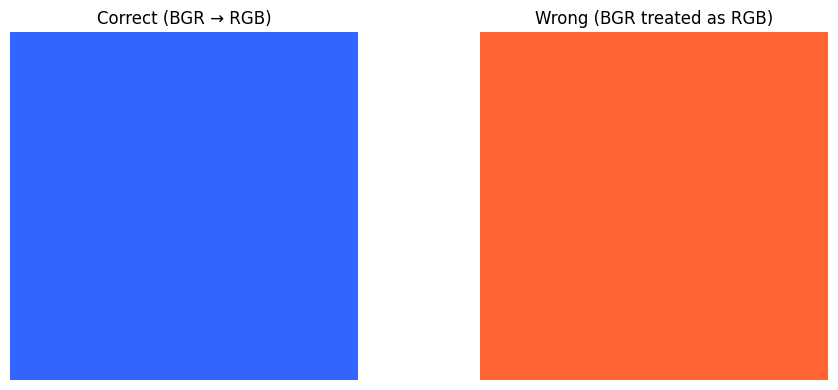


⚠️ Key lesson: OpenCV uses BGR by default, not RGB!


In [ ]:
# Create a simple 100x100 BGR image with a gradient
img = np.zeros((100, 100, 3), dtype=np.uint8)

# Fill with a solid color (BGR format: Blue=255, Green=100, Red=50)
img[:] = (255, 100, 50)  # Cyan-ish color

print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")
print(f"Pixel at (10, 10): {img[10, 10]}")
print(f"Value range: {img.min()} to {img.max()}")

# Display both BGR and RGB
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# OpenCV uses BGR, but matplotlib expects RGB
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Correct (BGR → RGB)")
axes[0].axis("off")

axes[1].imshow(img)  # Wrong: shows BGR as RGB
axes[1].set_title("Wrong (BGR treated as RGB)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\n⚠️ Key lesson: OpenCV uses BGR by default, not RGB!")

### Task A.1.1: Create and Manipulate a Simple Image

Create a 200×200 image and:
1. Set the top half to red (in BGR: `(0, 0, 255)`)
2. Set the bottom half to green (in BGR: `(0, 255, 0)`)
3. Draw a white rectangle in the center
4. Display it correctly using matplotlib

**Hint:** Use `cv2.rectangle(img, pt1, pt2, color, thickness)` to draw.

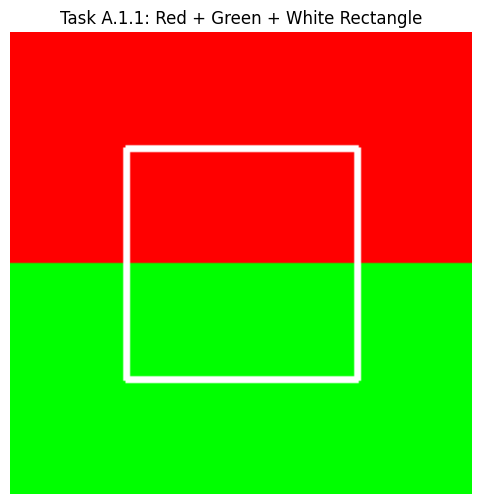

In [ ]:
# TODO: Create the image as described above
img_task = np.zeros((200, 200, 3), dtype=np.uint8)

# Set top half to red
img_task[0:100, :] = (0, 0, 255)

# Set bottom half to green
img_task[100:200, :] = (0, 255, 0)

# Draw a white rectangle in the center
cv2.rectangle(img_task, (50, 50), (150,150), (255,255,255), 2)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_task, cv2.COLOR_BGR2RGB))
plt.title("Task A.1.1: Red + Green + White Rectangle")
plt.axis("off")
plt.show()

## Part A.2 — Loading and Displaying Real Images

Let's download a sample image and explore it:

Image shape: (1198, 1200, 3)
Image dtype: uint8
Color space: BGR
Pixel range: 0 to 255


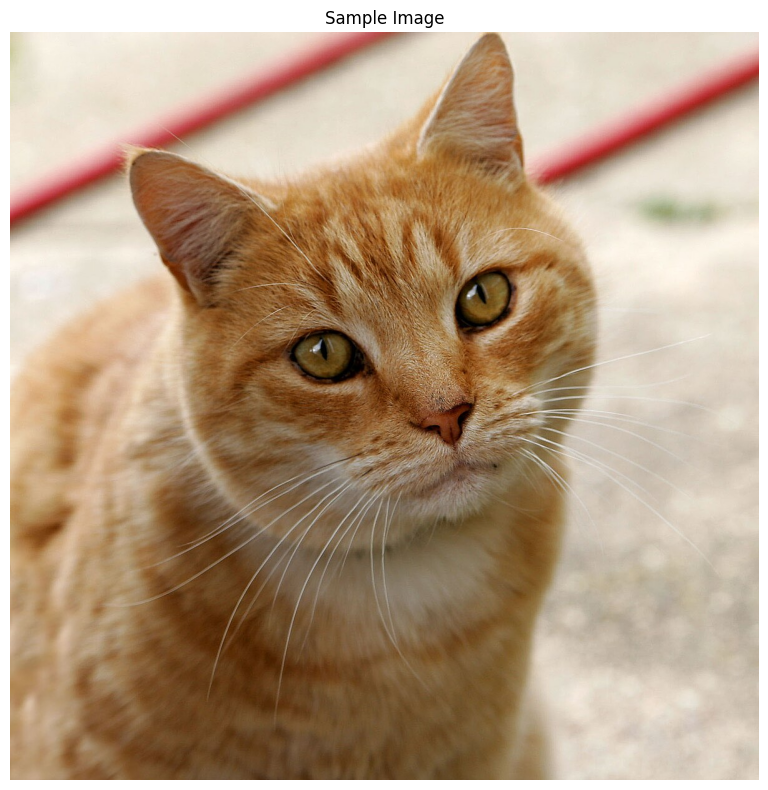

In [ ]:
import urllib.request
# Download a sample image
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"
image_path = "./cv_data/Cat03.jpg"

if not os.path.exists(image_path):
    print("Downloading sample image...")
    urllib.request.urlretrieve(url, image_path)
    print(f"Downloaded to {image_path}")

# Load the image
img = cv2.imread(image_path)

if img is None:
    print("Error: could not load image")
else:
    print(f"Image shape: {img.shape}")
    print(f"Image dtype: {img.dtype}")
    print(f"Color space: BGR")
    print(f"Pixel range: {img.min()} to {img.max()}")

    # Display
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Sample Image")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### Exploring Channels

Let's separate the color channels and visualize them:

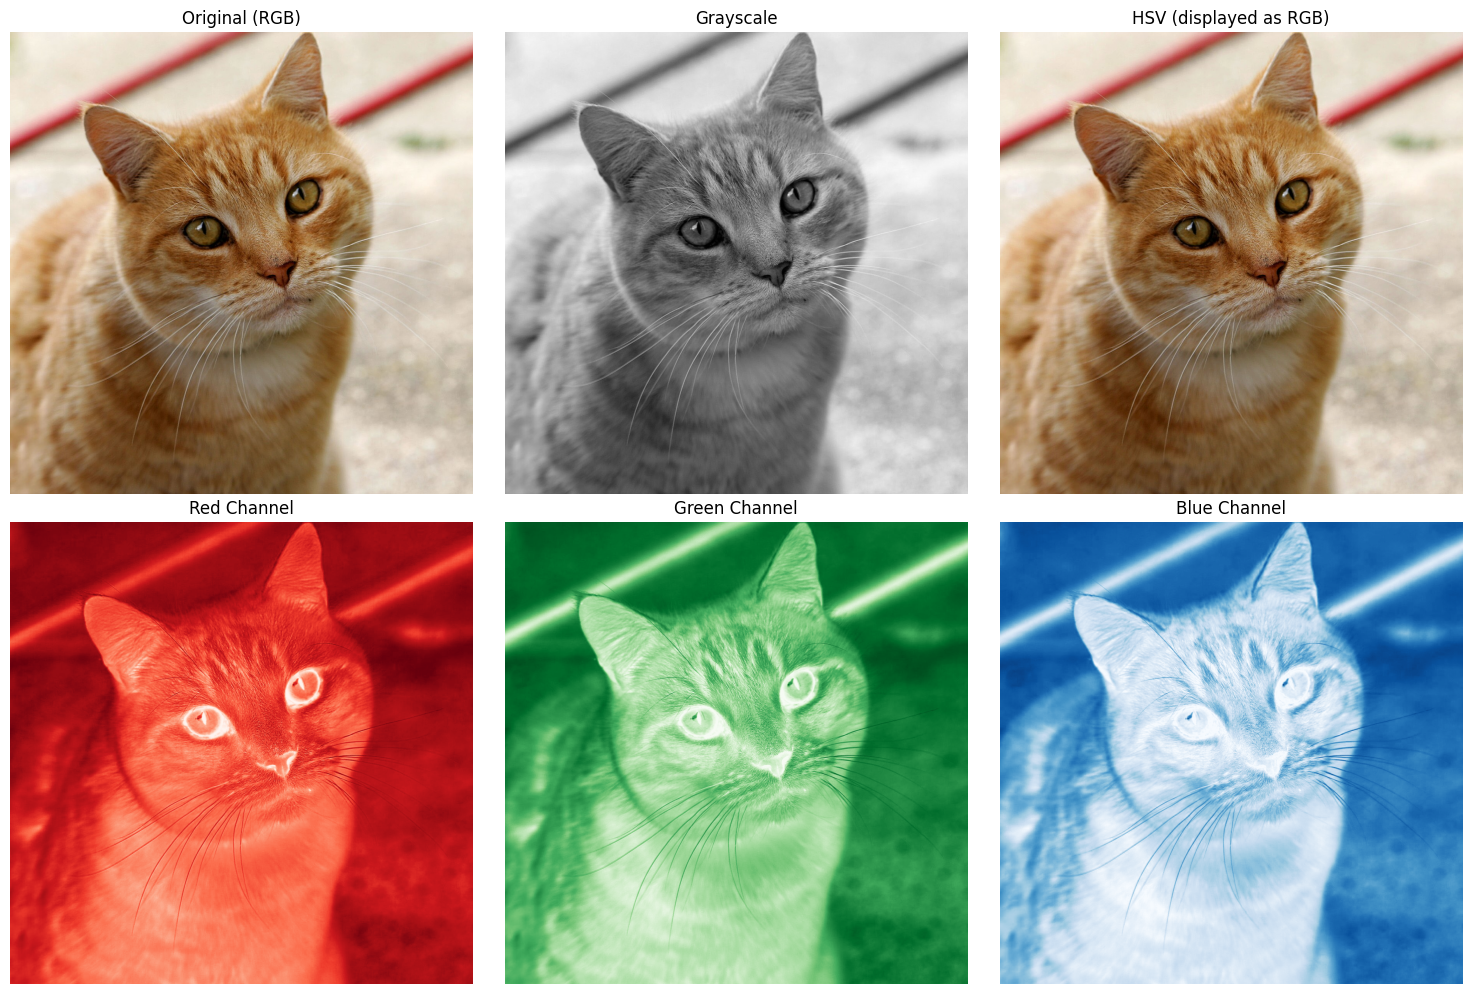

Grayscale shape: (1198, 1200)
HSV shape: (1198, 1200, 3)


In [ ]:
# Split into B, G, R channels
b, g, r = cv2.split(img)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original (RGB)")
axes[0, 0].axis("off")

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
axes[0, 1].imshow(gray, cmap="gray")
axes[0, 1].set_title("Grayscale")
axes[0, 1].axis("off")

# HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
axes[0, 2].imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
axes[0, 2].set_title("HSV (displayed as RGB)")
axes[0, 2].axis("off")

# Individual channels
axes[1, 0].imshow(r, cmap="Reds")
axes[1, 0].set_title("Red Channel")
axes[1, 0].axis("off")

axes[1, 1].imshow(g, cmap="Greens")
axes[1, 1].set_title("Green Channel")
axes[1, 1].axis("off")

axes[1, 2].imshow(b, cmap="Blues")
axes[1, 2].set_title("Blue Channel")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print(f"Grayscale shape: {gray.shape}")
print(f"HSV shape: {hsv.shape}")

## Part A.3 — Edge Detection (Canny)

**Edge detection** finds boundaries in an image. The **Canny edge detector** is one of the most popular methods.

Steps:
1. Apply Gaussian blur (smooth noise)
2. Compute image gradients (rate of change)
3. Apply non-maximum suppression (thin edges)
4. Apply hysteresis thresholding (connect edges)

Let's apply it:

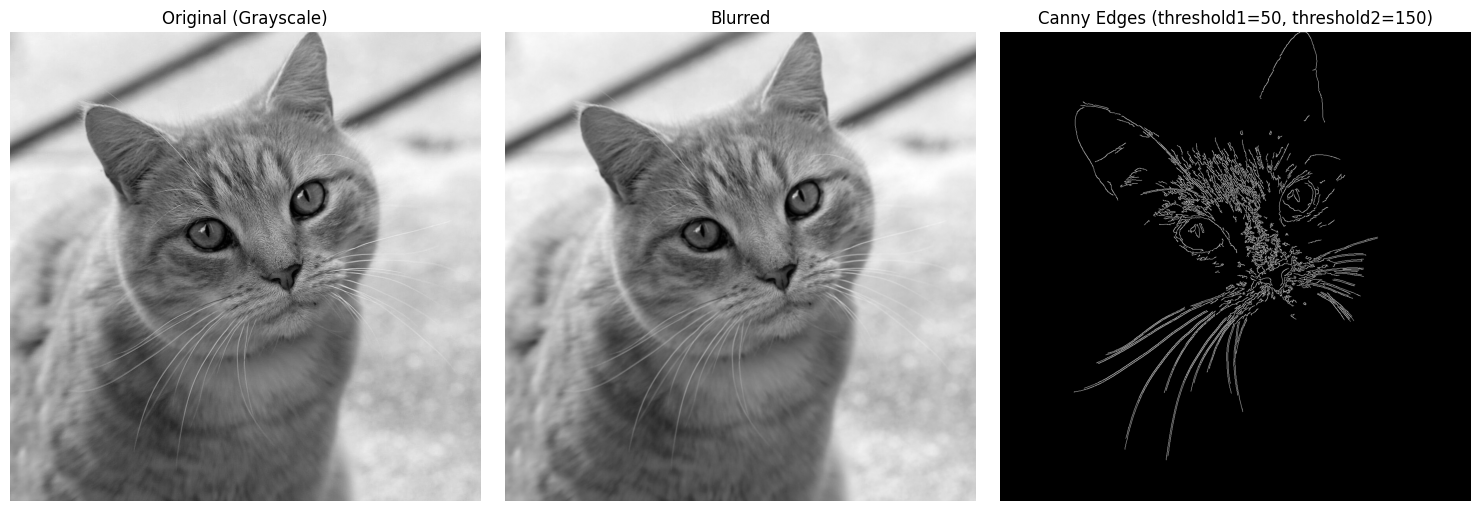

Edges shape: (1198, 1200)
Edges dtype: uint8
Number of edge pixels: 31235


In [ ]:
# Convert to grayscale first
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur
blurred = cv2.GaussianBlur(gray, (5, 5), 1.0)

# Apply Canny edge detection
# Parameters: image, lower_threshold, upper_threshold
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original (Grayscale)")
axes[0].axis("off")

axes[1].imshow(blurred, cmap="gray")
axes[1].set_title("Blurred")
axes[1].axis("off")

axes[2].imshow(edges, cmap="gray")
axes[2].set_title("Canny Edges (threshold1=50, threshold2=150)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Edges shape: {edges.shape}")
print(f"Edges dtype: {edges.dtype}")
print(f"Number of edge pixels: {np.count_nonzero(edges)}")

### Task A.3.1: Experiment with Thresholds

Try different threshold values for Canny edge detection. What happens if you use very low thresholds? Very high?

Report your observations:

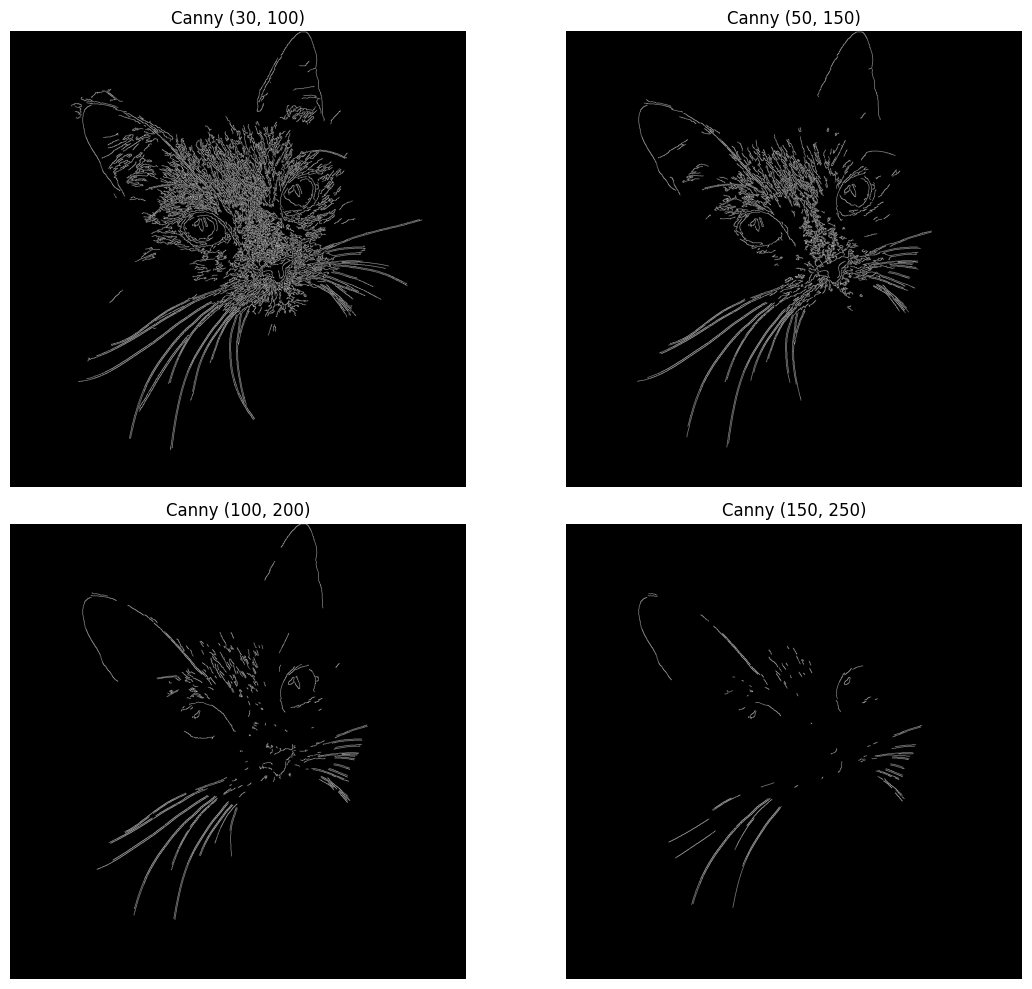

Observation: 
Lower thresholds: More edges are detected, but there is also more noise and extra detail.
Higher thresholds: Fewer edges are detected and the result is cleaner. Some real edges have disappear.


In [ ]:
# TODO: Create a 2x2 or 2x3 subplot showing different threshold combinations
# Try combinations like:
# (30, 100), (50, 150), (100, 200), (150, 250)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

threshold_pairs = [(30, 100), (50, 150), (100, 200), (150, 250)]

for idx, (lower, upper) in enumerate(threshold_pairs):
    edges_exp = cv2.Canny(blurred, threshold1=lower, threshold2=upper)
    axes[idx].imshow(edges_exp, cmap="gray")
    axes[idx].set_title(f"Canny ({lower}, {upper})")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

print("Observation: ")
print("Lower thresholds: More edges are detected, but there is also more noise and extra detail.")
print("Higher thresholds: Fewer edges are detected and the result is cleaner. Some real edges have disappear.")

## Part A.4 — Contour Detection

**Contours** are curves that connect points of the same color or intensity.

After edge detection, we can extract contours and use them to:
- approximate object shapes,
- compute area and perimeter,
- find bounding boxes,
- segment objects.

Let's find and draw contours:

Number of contours found: 546


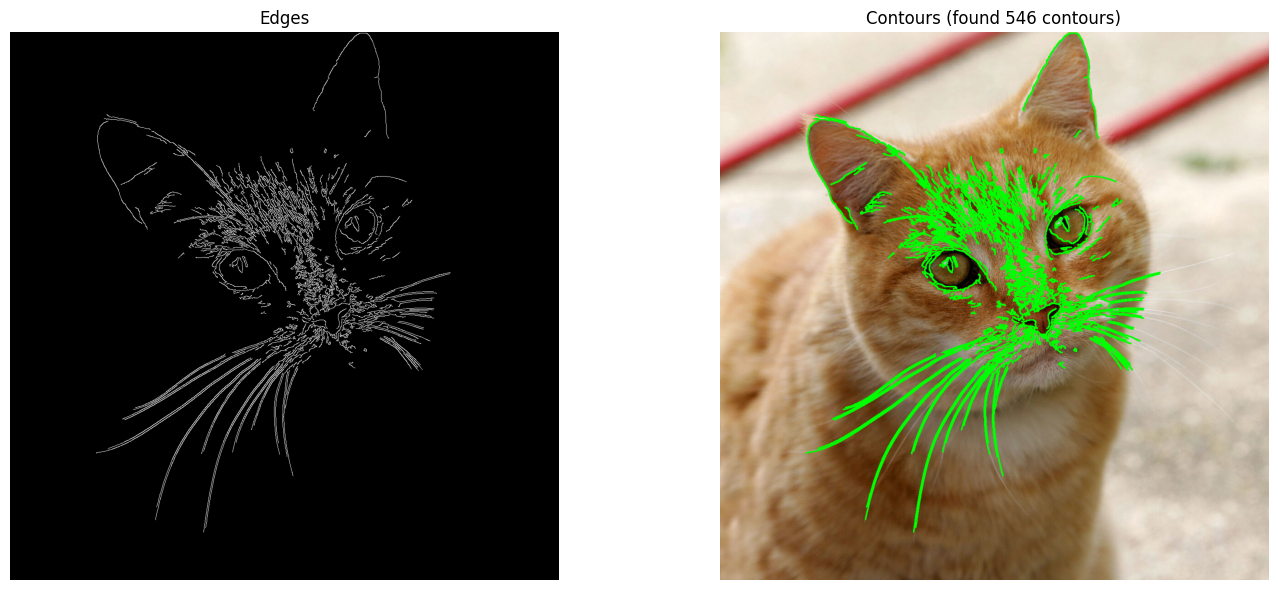

In [ ]:
# Find contours from edges
contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

print(f"Number of contours found: {len(contours)}")

# Draw contours on the original image
img_with_contours = img.copy()
cv2.drawContours(img_with_contours, contours, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Edges")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_with_contours, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Contours (found {len(contours)} contours)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Finding the Largest Contour

Often, we're interested in the largest contour:

Largest contour:
  Area: 438.50 pixels²
  Perimeter: 1809.75 pixels
  Bounding box: (354, 241), width=183, height=190


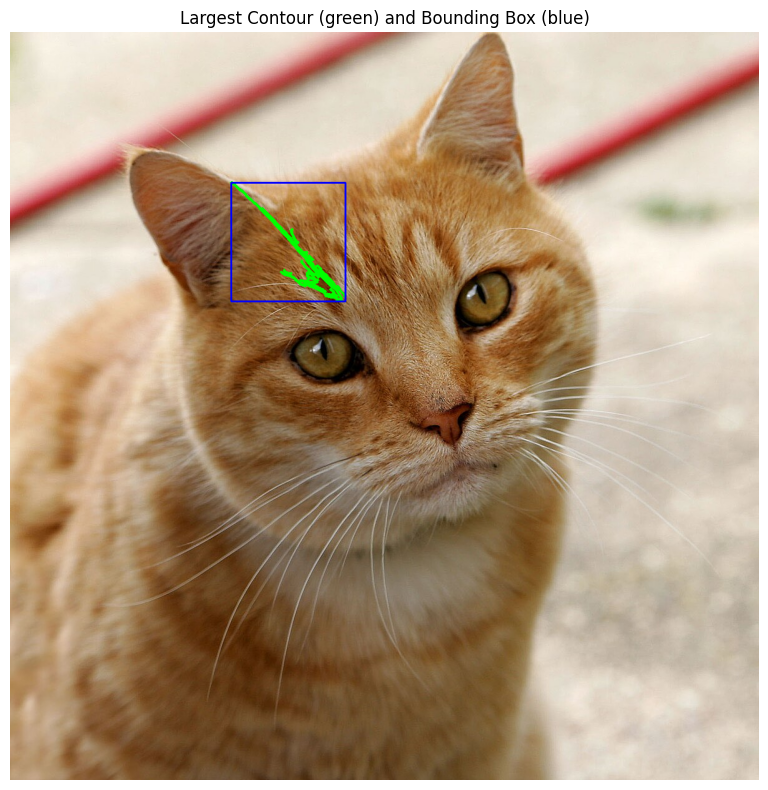

In [ ]:
if len(contours) > 0:
    # Sort contours by area
    contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    largest_contour = contours_sorted[0]

    area = cv2.contourArea(largest_contour)
    perimeter = cv2.arcLength(largest_contour, closed=True)

    print(f"Largest contour:")
    print(f"  Area: {area:.2f} pixels²")
    print(f"  Perimeter: {perimeter:.2f} pixels")

    # Get bounding rectangle
    x, y, w, h = cv2.boundingRect(largest_contour)
    print(f"  Bounding box: ({x}, {y}), width={w}, height={h}")

    # Draw the largest contour
    img_largest = img.copy()
    cv2.drawContours(img_largest, [largest_contour], 0, (0, 255, 0), 3)
    cv2.rectangle(img_largest, (x, y), (x+w, y+h), (255, 0, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_largest, cv2.COLOR_BGR2RGB))
    plt.title(f"Largest Contour (green) and Bounding Box (blue)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Part A.5 — Video Fundamentals

### What is a Video?

A video is simply a **sequence of frames** played in rapid succession.

Key concepts:
- **Frame:** a single image
- **FPS (frames per second):** how many frames play per second (e.g., 24, 30, 60)
- **Codec:** algorithm that compresses video (e.g., H.264, VP9, MJPEG)
- **Container:** file format that stores video + audio (e.g., MP4, AVI, MOV)
- **Resolution:** frame width × height (e.g., 1920×1080)
- **Bitrate:** data rate (measured in kbps or Mbps)

### Creating a Simple Video

Let's create a short video with animated frames:

In [ ]:
# Video properties
output_path = "./cv_data/simple_video.avi"
width, height = 400, 300
fps = 30
num_frames = 90  # 3 seconds at 30 fps

# Define the codec and create VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'MJPG')  # MJPEG codec
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print(f"Creating video: {output_path}")
print(f"Resolution: {width}x{height}")
print(f"FPS: {fps}")
print(f"Total frames: {num_frames}")

# Generate frames: a moving circle
for frame_idx in range(num_frames):
    # Create a blank frame
    frame = np.zeros((height, width, 3), dtype=np.uint8)

    # Draw a moving circle
    circle_x = int(100 + 80 * np.sin(2 * np.pi * frame_idx / num_frames))
    circle_y = int(height // 2)

    cv2.circle(frame, (circle_x, circle_y), 30, (0, 255, 255), -1)
    cv2.putText(frame, f"Frame {frame_idx}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    out.write(frame)

out.release()
print(f"Video saved!")

Creating video: ./cv_data/simple_video.avi
Resolution: 400x300
FPS: 30
Total frames: 90
Video saved!


### Loading a Video and Extracting Metadata

Now let's read the video we just created and extract metadata:

Video Metadata:
  Resolution: 400x300
  FPS: 30.0
  Total frames: 90
  Duration: 3.00 seconds
  Codec (fourcc): MJPG


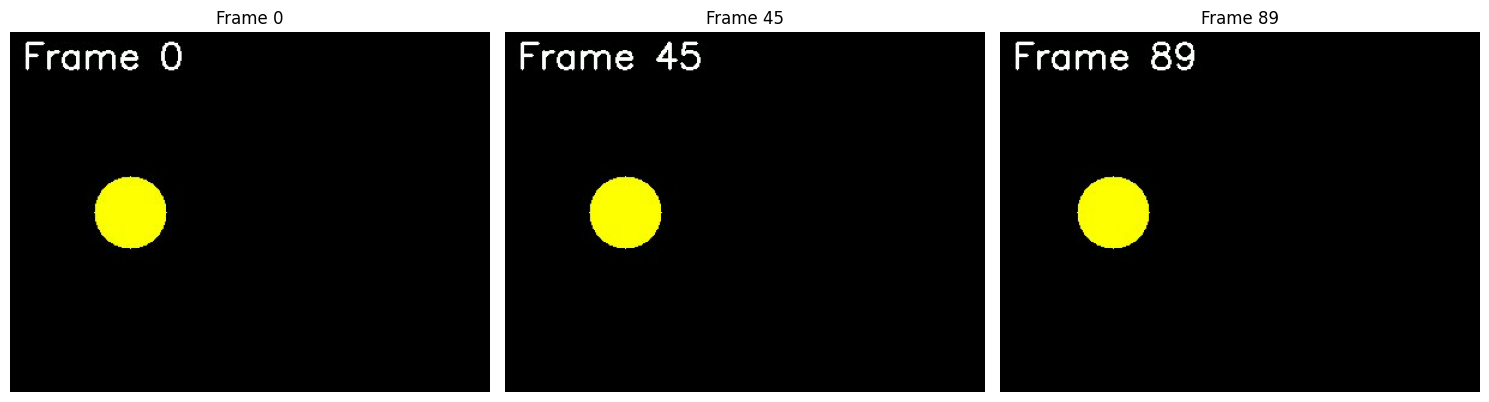

In [ ]:
# Open the video
cap = cv2.VideoCapture(output_path)

if not cap.isOpened():
    print("Error: could not open video")
else:
    # Extract metadata
    fps = cap.get(cv2.CAP_PROP_FPS)  # Frames per second
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc_code = int(cap.get(cv2.CAP_PROP_FOURCC))

    # Decode fourcc
    fourcc_str = "".join([chr((fourcc_code >> 8*i) & 0xFF) for i in range(4)])

    duration_seconds = total_frames / fps if fps > 0 else 0

    print("Video Metadata:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {duration_seconds:.2f} seconds")
    print(f"  Codec (fourcc): {fourcc_str}")

    # Read and display a few frames
    frame_indices = [0, total_frames // 2, total_frames - 1]
    frames_to_show = []

    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            frames_to_show.append((frame_idx, frame))

    cap.release()

    # Display frames
    fig, axes = plt.subplots(1, len(frames_to_show), figsize=(15, 5))
    for ax, (frame_idx, frame) in zip(axes, frames_to_show):
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Frame {frame_idx}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Task A.5.1: Video Processing

Write code to:
1. Load the video we created,
2. Extract every 10th frame,
3. Convert each frame to grayscale,
4. Apply Canny edge detection,
5. Display a grid of the processed frames.

This demonstrates a typical video processing pipeline:

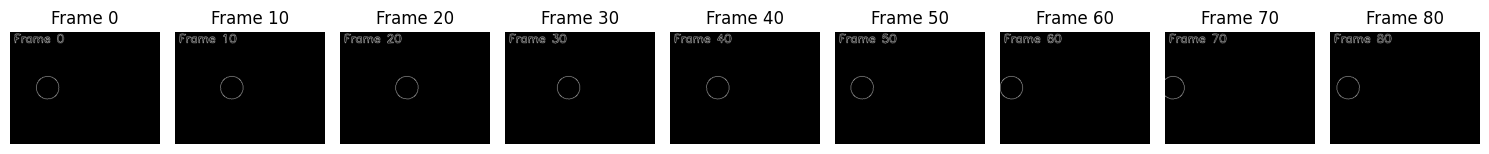

Extracted and processed 9 frames


In [ ]:
# TODO: Implement video processing pipeline
cap = cv2.VideoCapture(output_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

processed_frames = []
frame_indices = []

# TODO: Extract every 10th frame, convert to grayscale, apply Canny
for frame_idx in range(0,total_frames,10):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if ret:
        gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
        edges=cv2.Canny(gray,threshold1=50,threshold2=150)
        processed_frames.append(edges)
        frame_indices.append(frame_idx)

cap.release()

# TODO: Display the processed frames in a grid
fig,axes=plt.subplots(1,len(processed_frames),figsize=(15,5))
for ax, (frame_idx, edge_img) in zip(axes, zip(frame_indices, processed_frames)):
    ax.imshow(edge_img, cmap="gray")
    ax.set_title(f"Frame {frame_idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Extracted and processed {len(processed_frames)} frames")

---

# PART B: PyTorch Fundamentals & Deep Learning

Now that you understand how images and videos work in Python, let's move into **deep learning with PyTorch**.

## Part B.0 — Setup

Run the next cell first.

This cell imports PyTorch, sets a random seed, and checks whether a GPU is available.

### Why this matters
- **Reproducibility:** setting a seed makes random operations consistent.
- **Device selection:** training on GPU is much faster than CPU.
- **Library versions:** practical debugging often starts by checking package versions.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__)

Using device: cuda
PyTorch version: 2.10.0+cu128


## Part B.1 — PyTorch Tensors: A Quick Practical Introduction

Before we build neural networks, we need to understand **tensors**.

A tensor in PyTorch has:
- a **shape**: size of each dimension,
- a **dimension count**: number of axes,
- a **dtype**: data type (float, integer, etc.),
- a **device**: CPU or GPU.

### Common tensor shapes in computer vision:
- Scalar → shape `[]`
- Vector → shape `(N,)`
- Matrix → shape `(H, W)`
- **Single grayscale image** → shape `(H, W)` or `(1, H, W)`
- **Single color image (PyTorch)** → shape `(C, H, W)` where C=3 for RGB
- **Batch of images** → shape `(B, C, H, W)`

Read more: https://docs.pytorch.org/docs/stable/tensors.html

In [ ]:
# Examples: creating tensors
import torch

scalar = torch.tensor(7)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1, 2, 3],
                       [4, 5, 6]])
three_d = torch.rand(2, 3, 4)

zeros = torch.zeros(2, 5)
ones = torch.ones(3, 3)
random_tensor = torch.randn(4, 4)

examples = {
    "scalar": scalar,
    "vector": vector,
    "matrix": matrix,
    "three_d": three_d,
    "zeros": zeros,
    "ones": ones,
    "random_tensor": random_tensor,
}

for name, t in examples.items():
    print(f"{name:14s} shape={tuple(t.shape)}, ndim={t.ndim}, dtype={t.dtype}")

scalar         shape=(), ndim=0, dtype=torch.int64
vector         shape=(3,), ndim=1, dtype=torch.float32
matrix         shape=(2, 3), ndim=2, dtype=torch.int64
three_d        shape=(2, 3, 4), ndim=3, dtype=torch.float32
zeros          shape=(2, 5), ndim=2, dtype=torch.float32
ones           shape=(3, 3), ndim=2, dtype=torch.float32
random_tensor  shape=(4, 4), ndim=2, dtype=torch.float32


## Part B.1.1 — Basic Tensor Computation

PyTorch tensors support the operations we need in deep learning:

In [ ]:
# Examples: computation on tensors

a = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])
b = torch.tensor([[10.0, 20.0],
                  [30.0, 40.0]])

print("a + b =\n", a + b)
print("\na * b (element-wise) =\n", a * b)
print("\na.mean() =", a.mean().item())

x = torch.arange(12).float()
print("\nOriginal x shape:", x.shape)

x_reshaped = x.view(3, 4)
print("Reshaped x to (3, 4):", x_reshaped.shape)

u = torch.tensor([[1.0, 2.0, 3.0]])
v = torch.tensor([[1.0], [2.0], [3.0]])
print("\nMatrix multiply u @ v =", (u @ v).item())

img = torch.rand(28, 28)
print("\nSingle grayscale image shape:", img.shape)
img_batch = img.unsqueeze(0).unsqueeze(0)  # add batch and channel dimensions
print("After unsqueeze -> batch shape:", img_batch.shape)

a + b =
 tensor([[11., 22.],
        [33., 44.]])

a * b (element-wise) =
 tensor([[ 10.,  40.],
        [ 90., 160.]])

a.mean() = 2.5

Original x shape: torch.Size([12])
Reshaped x to (3, 4): torch.Size([3, 4])

Matrix multiply u @ v = 14.0

Single grayscale image shape: torch.Size([28, 28])
After unsqueeze -> batch shape: torch.Size([1, 1, 28, 28])


## Part B.1.2 — Task: Tensor Operations

### Task B.1: Image Tensor Shapes

Create the following tensors:
1. A random grayscale image of shape `(28, 28)`
2. A random RGB image of shape `(3, 28, 28)`
3. A batch of 16 RGB images of shape `(16, 3, 28, 28)`

Print the shape of each.

In [ ]:
# TODO: create the requested tensors and print their shapes

gray_img = torch.rand(28,28)
rgb_img = torch.rand(3,28,28)
batch_img = torch.rand(16, 3, 28, 28)

print("gray_img shape:", gray_img.shape)
print("rgb_img shape:", rgb_img.shape)
print("batch_img shape:", batch_img.shape)

gray_img shape: torch.Size([28, 28])
rgb_img shape: torch.Size([3, 28, 28])
batch_img shape: torch.Size([16, 3, 28, 28])


### Task B.2: Why (C, H, W) instead of (H, W, C)?

Why does PyTorch store image tensors as **(C, H, W)** instead of **(H, W, C)**?

Write 2–4 sentences:

**Your answer:**

PyTorch stores image tensors as (C, H, W) instead of (H, W, C) for computational efficiency. By grouping pixels of a channel together, GPUs can perform convolutions in parallel, which is faster.

### Task B.3: Indexing and Slicing

Index into your RGB image and display:
- the full image shape,
- the red channel shape,
- the value of one pixel for all 3 channels.

Complete the code below:

In [ ]:
# TODO
print("Full image shape:", rgb_img.shape)
print("Red channel shape:", rgb_img[0].shape)

row, col = 10, 15
print("Pixel values at (10, 15):", rgb_img[:,row,col])

Full image shape: torch.Size([3, 28, 28])
Red channel shape: torch.Size([28, 28])
Pixel values at (10, 15): tensor([0.5341, 0.4723, 0.6284])


## Part B.2 — Load FashionMNIST Dataset

We will use **FashionMNIST**, a small image dataset of clothing items. It has:
- 60,000 training images
- 10,000 test images
- 10 classes (T-shirt, trouser, pullover, etc.)
- Grayscale 28×28 images

A **DataLoader** groups samples into batches, shuffles data, and feeds it to models during training.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

# Complete dataset loading
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# TODO: Create data loaders with batch_size=64
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

class_names = train_dataset.classes
print(class_names)
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training samples: 60000
Test samples: 10000


### Task B.4: Visualize a Batch

Display the first 8 images from one training batch with their labels:

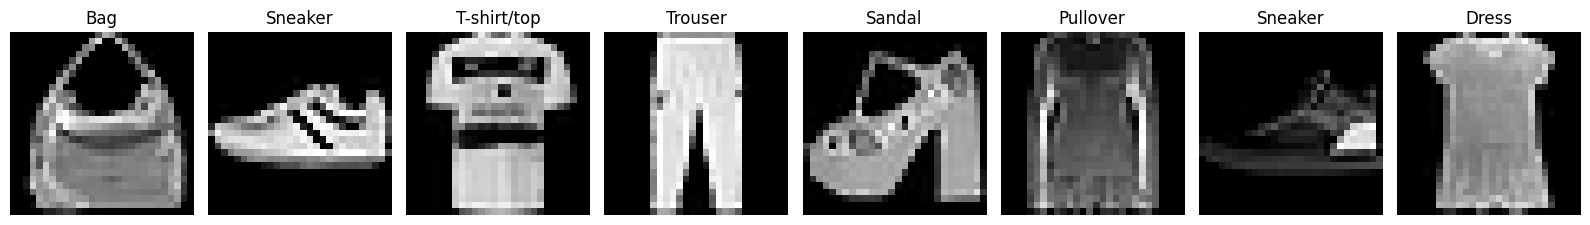

Batch shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


In [ ]:
images, labels = next(iter(train_loader))

# TODO: visualize first 8 images
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    img = images[i].squeeze(0)  # Extract single image from batch
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("Batch shape:", images.shape)
print("Label shape:", labels.shape)

### Task B.5: Batch Shape Explanation

Based on the batch shape you printed:
1. What does each dimension mean?
2. Why is there a channel dimension even for grayscale?

**Your answer:**

1.
- 64 is the numbers of images processed per batch
- 1 is the number of colour channels (greyscale)
- 28 is the height of the images in pixels
- 28 is the width of the images in pixels

2.
- There is a channel dimension even for the case of grayscale to have consistency in the algorithm. Some functions used in image analysis expect the channel dimension to be defined.




## Part B.3 — Build a Fully Connected Baseline

Before using a CNN, we build a **fully connected neural network (FCN)** baseline.

This reinforces why **flattening destroys spatial structure**.

A fully connected layer expects a 1D vector, so the image must be flattened from `(1, 28, 28)` into `784` values.

### Task B.6: Implement FCN

Complete the FCN class:
- Flatten input
- Linear: `28×28 → 128`
- ReLU
- Linear: `128 → 10`

In [ ]:
class FCNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            # TODO: add layers
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

fcn_model = FCNClassifier().to(device)
print(fcn_model)

FCNClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Training and Evaluation Functions

These are core PyTorch patterns used in almost every project:

In [ ]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # TODO: complete the training loop
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # TODO: complete evaluation
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

### Task B.7: Train the FCN

Train for 3 epochs using:
- Loss: `nn.CrossEntropyLoss()`
- Optimizer: Adam with learning rate `1e-3`

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(fcn_model.parameters(), lr=1e-3)

fcn_history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(3):
    train_loss, train_acc = train_one_epoch(fcn_model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = evaluate(fcn_model, test_loader, loss_fn, device)

    fcn_history["train_loss"].append(train_loss)
    fcn_history["train_acc"].append(train_acc)
    fcn_history["test_loss"].append(test_loss)
    fcn_history["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Epoch 1: train_loss=0.5494, train_acc=0.8111, test_loss=0.4508, test_acc=0.8403
Epoch 2: train_loss=0.4015, train_acc=0.8576, test_loss=0.4157, test_acc=0.8522
Epoch 3: train_loss=0.3571, train_acc=0.8719, test_loss=0.3877, test_acc=0.8559


### Task B.8: Analyze FCN Performance

Report your final test accuracy and answer: 0.8559 (≈ 85.59%)

**Why is a fully connected network not ideal for image data?**

**Your answer:**

Fully connected networks ignore the spatial nature of images and are inefficient, whereas CNNs are specifically designed to handle image data effectively.

---

## Congratulations!

You've completed the core parts of this lab:
- ✅ Image fundamentals (loading, channels, transformations)
- ✅ Image processing (edge detection, contours)
- ✅ Video basics (creating, loading, metadata)
- ✅ PyTorch tensors and operations
- ✅ Loading real datasets
- ✅ Building and training a baseline FCN

**Optional extensions** (CNNs, more experiments) can be added in subsequent versions.

---

## Grading Rubric

| Component | Marks |
|---|---:|
| Image fundamentals (A.1–A.2) | 15 |
| Edge detection & contours (A.3–A.4) | 15 |
| Video basics (A.5–A.5.1) | 10 |
| Tensor basics (B.1–B.3) | 10 |
| Dataset loading and visualization (B.4–B.5) | 10 |
| FCN implementation and training (B.6–B.8) | 20 |
| Code quality & documentation | 10 |
| Written explanations & reflections | 10 |

**Total = 100**

In [ ]:
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-latex-extra

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-latex-extra is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 54 not upgraded.


In [ ]:
!jupyter nbconvert --to pdf "/content/DATA589_Lab1_CV_Foundations_PyTorch.ipynb"

[NbConvertApp] Converting notebook /content/DATA589_Lab1_CV_Foundations_PyTorch.ipynb to pdf
[NbConvertApp] Support files will be in DATA589_Lab1_CV_Foundations_PyTorch_files/
[NbConvertApp] Making directory ./DATA589_Lab1_CV_Foundations_PyTorch_files
[NbConvertApp] Writing 119231 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 4330513 bytes to /content/DATA589_Lab1_CV_Foundations_PyTorch.pdf


In [ ]:
!apt-get update

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
